## 3. Modeling TF-IDF x LSTM

### 3.1 Importing the Libraries 

In [43]:
import pickle
import os 
import matplotlib.pyplot as plt
import numpy as np 
import seaborn as sns 

from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Dense, Embedding, LSTM, Input, Concatenate, Dropout)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import AdamW 

### 3.2 Define the Parameter

In [44]:
VOCAB_SIZE = 5000
TFIDF_FEATURES = 5000
MAX_LEN = 200
MODEL_SAVE_PATH = "../models/lstm_model.keras"

### 3.2 Load the Dataset

In [45]:
X_train_pad   = pickle.load(open("../dataset/processed/02_after_FE/X_train_pad.pkl", "rb"))
X_train_tfidf = pickle.load(open("../dataset/processed/02_after_FE/X_train_tfidf.pkl", "rb"))
y_train       = pickle.load(open("../dataset/processed/02_after_FE/y_train.pkl", "rb"))

X_test_pad    = pickle.load(open("../dataset/processed/02_after_FE/X_test_pad.pkl", "rb"))
X_test_tfidf  = pickle.load(open("../dataset/processed/02_after_FE/X_test_tfidf.pkl", "rb"))
y_test        = pickle.load(open("../dataset/processed/02_after_FE/y_test.pkl", "rb"))

### 3.3 Konversi Data Type

In [ ]:
# Input Sequence (X_pad) HARUS INT32 untuk Embedding Layer
X_train_pad   = np.array(X_train_pad, dtype='int32') 
X_test_pad    = np.array(X_test_pad, dtype='int32')   

# Input TFIDF dan Label tetap FLOAT32
X_train_tfidf = np.array(X_train_tfidf, dtype='float32')
X_test_tfidf  = np.array(X_test_tfidf, dtype='float32')

y_train = np.array(y_train, dtype='float32')
y_test  = np.array(y_test, dtype='float32')

### 3.4 Check Array Dimension

In [47]:
print(f"Shape X_train_pad: {X_train_pad.shape}")
print(f"Shape X_train_tfidf: {X_train_tfidf.shape}")
print(f"Shape y_train: {y_train.shape}")
print(f"Shape y_test: {y_test.shape}")

Shape X_train_pad: (30816, 200)
Shape X_train_tfidf: (30816, 5000)
Shape y_train: (30816,)
Shape y_test: (4178,)


In [48]:
# === ASSERTION CHECK (important!) ===
assert X_train_pad.shape[0] == X_train_tfidf.shape[0] == y_train.shape[0], \
    "Mismatch: jumlah sample antara sequence, tfidf, dan label tidak sama!"

assert X_test_pad.shape[0] == X_test_tfidf.shape[0] == y_test.shape[0], \
    "Mismatch: jumlah sample test tidak sama!"

### 3.4 Build LSTM Model with TF-IDF

In [49]:
# Sequence
input_seq = Input(shape=(MAX_LEN,), name='input_sequence')

x = Embedding(input_dim=VOCAB_SIZE, output_dim=64)(input_seq) 

x = LSTM(32)(x) 
x = Dropout(0.5)(x) 

# TF-IDF 
input_tfidf = Input(shape=(TFIDF_FEATURES,), name='input_tfidf') 
y = Dense(16, activation='relu')(input_tfidf) 
y = Dropout(0.3)(y) # Tambah dikit biar imbang sama sequence

# Concate
combined = Concatenate()([x, y])

z = Dense(32, activation="relu")(combined) 
z = Dropout(0.5)(z) 
output_layer = Dense(1, activation="sigmoid")(z)

# Define model
model = Model(inputs=[input_seq, input_tfidf], outputs=output_layer)

optimizer = AdamW(learning_rate=0.0001, weight_decay=0.004)

model.compile(
    loss='binary_crossentropy',
    optimizer=optimizer, 
    metrics=['accuracy']
)
print(model.summary())

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_sequence      │ (None, 200)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, 200, 64)   │    320,000 │ input_sequence[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_tfidf         │ (None, 5000)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ (None, 32)        │     12,416 │ embedding_3[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 16)        │     80,016 │ input_tfidf[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 32)        │          0 │ lstm_3[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 16)        │          0 │ dense_9[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 48)        │          0 │ dropout_9[0][0],  │
│ (Concatenate)       │                   │            │ dropout_10[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 32)        │      1,568 │ concatenate_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 32)        │          0 │ dense_10[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 1)         │         33 │ dropout_11[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 414,033 (1.58 MB)

 Trainable params: 414,033 (1.58 MB)

 Non-trainable params: 0 (0.00 B)

None


### 3.5 Define Callbacks

In [50]:
early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=3, 
    restore_best_weights=True,
    verbose=1
)

### 3.6 Training

In [51]:
history = model.fit(
    [X_train_pad, X_train_tfidf],
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
386/386 ━━━━━━━━━━━━━━━━━━━━ 13s 25ms/step - accuracy: 0.7902 - loss: 0.4850 - val_accuracy: 0.8868 - val_loss: 0.5538
Epoch 2/50
386/386 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.9748 - loss: 0.1732 - val_accuracy: 0.9849 - val_loss: 0.1668
Epoch 3/50
386/386 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.9877 - loss: 0.0724 - val_accuracy: 0.9951 - val_loss: 0.0575
Epoch 4/50
386/386 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.9927 - loss: 0.0398 - val_accuracy: 0.9992 - val_loss: 0.0282
Epoch 5/50
386/386 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.9957 - loss: 0.0273 - val_accuracy: 1.0000 - val_loss: 0.0154
Epoch 6/50
386/386 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.9973 - loss: 0.0191 - val_accuracy: 1.0000 - val_loss: 0.0116
Epoch 7/50
386/386 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.9976 - loss: 0.0137 - val_accuracy: 1.0000 - val_loss: 0.0053
Epoch 8/50
386/386 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.9962 - loss: 0.0207 - val_acc

### 3.7 Evaluation

In [52]:
loss, acc = model.evaluate([X_test_pad, X_test_tfidf], y_test, verbose=1)
print(f"\nAkurasi Test (LSTM + TF-IDF): {acc:.4f}")

131/131 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9816 - loss: 0.1270

Akurasi Test (LSTM + TF-IDF): 0.9816


#### 3.7.1 Training and Validation Loss

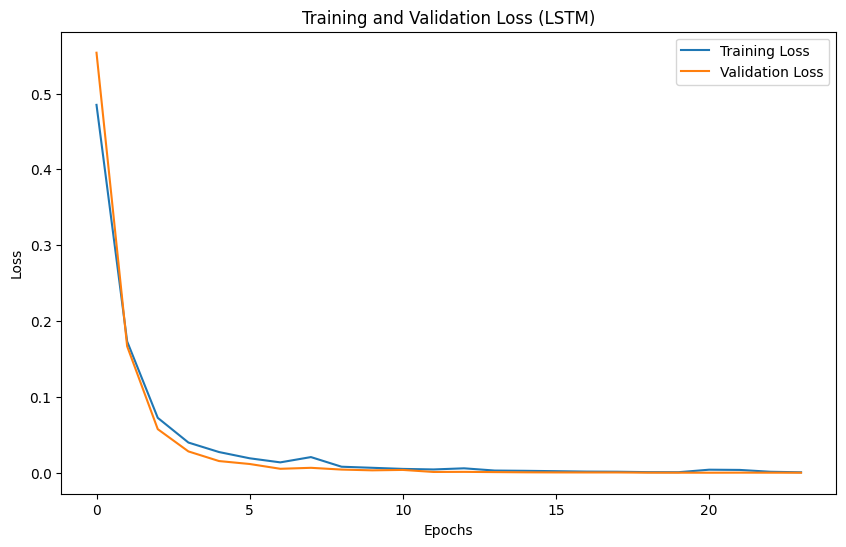

In [53]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss (LSTM)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

#### 3.7.2 Confusion Matrix

131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


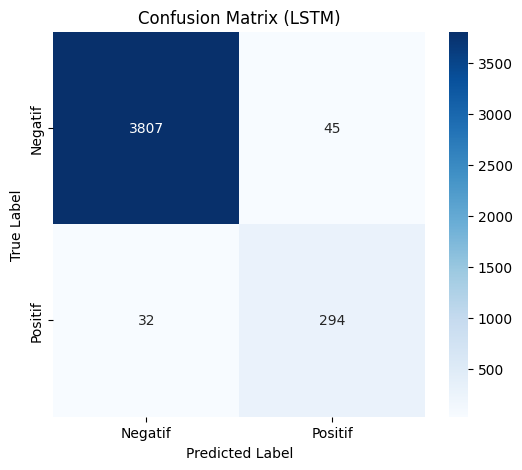

              precision    recall  f1-score   support

     Negatif       0.99      0.99      0.99      3852
     Positif       0.87      0.90      0.88       326

    accuracy                           0.98      4178
   macro avg       0.93      0.95      0.94      4178
weighted avg       0.98      0.98      0.98      4178



In [54]:
y_pred_prob = model.predict([X_test_pad, X_test_tfidf])
y_pred = (y_pred_prob > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negatif', 'Positif'],
            yticklabels=['Negatif', 'Positif'])
plt.title('Confusion Matrix (LSTM)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

print(classification_report(y_test, y_pred, target_names=['Negatif', 'Positif']))

### 3.8 Save Model

In [55]:
os.makedirs("../models", exist_ok=True) 
model.save(MODEL_SAVE_PATH)
print("Model LSTM saved to:", MODEL_SAVE_PATH)

Model LSTM saved to: ../models/lstm_model.keras


### 3.9 Addition

In [56]:
best_epoch_index = np.argmin(history.history['val_loss'])
best_val_loss = history.history['val_loss'][best_epoch_index]

print(f"Model mulai menghafal sekitar epoch: {best_epoch_index + 1}")
print(f"Validation Loss terendah (Best Epoch): {best_val_loss:.4f}")

Model mulai menghafal sekitar epoch: 21
Validation Loss terendah (Best Epoch): 0.0001
